In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from pathlib import Path

drive_path = Path("/content/drive/MyDrive")

if drive_path.exists():
    print("✅ Google Drive mounted successfully.")
else:
    print("❌ Google Drive mounting failed.")

✅ Google Drive mounted successfully.


In [3]:
# ============================================================
# STEP 2 : Project Configuration
# ============================================================

from pathlib import Path

# ----------------------------
# Project Paths
# ----------------------------
PROJECT_DIR = Path("/content/drive/MyDrive/UrbanFix")
DATASET_DIR = PROJECT_DIR / "UrbanFix_Dataset"

# ----------------------------
# Output Directories
# ----------------------------
MODEL_DIR = PROJECT_DIR / "Models"
OUTPUT_DIR = PROJECT_DIR / "Outputs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Dataset Parameters
# ----------------------------
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
IMAGE_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)

BATCH_SIZE = 32
VALIDATION_SPLIT = 0.20
SEED = 42

# ----------------------------
# Training Parameters
# ----------------------------
LEARNING_RATE = 1e-3
EPOCHS = 25

print("✅ Configuration Loaded Successfully")

✅ Configuration Loaded Successfully


In [4]:
# ============================================================
# Verify Dataset Path
# ============================================================

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset folder not found:\n{DATASET_DIR}"
    )

print("✅ Dataset found.\n")
print(f"Dataset Location:\n{DATASET_DIR}")

✅ Dataset found.

Dataset Location:
/content/drive/MyDrive/UrbanFix/UrbanFix_Dataset


In [5]:
from pathlib import Path

DATASET_DIR = Path("/content/drive/MyDrive/UrbanFix/UrbanFix_Dataset")

print("Class folders:\n")

for folder in sorted(DATASET_DIR.iterdir()):
    if folder.is_dir():
        print(folder.name)

Class folders:

DrainageIssue
FallenTree
GarbageOverflow
RoadDamage_Pothole
StreetLightIssues
WaterLeakage
WaterLogging
Waterpollution


In [6]:
# ============================================================
# STEP 3 : Dataset Inspection
# ============================================================

from pathlib import Path
from PIL import Image
import pandas as pd

In [7]:
# ============================================================
# Verify Dataset Structure
# ============================================================

if not DATASET_DIR.exists():
    raise FileNotFoundError(f"Dataset not found:\n{DATASET_DIR}")

class_names = sorted(
    [folder.name for folder in DATASET_DIR.iterdir() if folder.is_dir()]
)

print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)

print(f"Dataset Path      : {DATASET_DIR}")
print(f"Number of Classes : {len(class_names)}")

print("\nClasses:")

for index, cls in enumerate(class_names, start=1):
    print(f"{index}. {cls}")

DATASET INFORMATION
Dataset Path      : /content/drive/MyDrive/UrbanFix/UrbanFix_Dataset
Number of Classes : 8

Classes:
1. DrainageIssue
2. FallenTree
3. GarbageOverflow
4. RoadDamage_Pothole
5. StreetLightIssues
6. WaterLeakage
7. WaterLogging
8. Waterpollution


In [8]:
# ============================================================
# Count Images in Each Class
# ============================================================

VALID_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

dataset_summary = []

total_images = 0

for cls in class_names:

    class_path = DATASET_DIR / cls

    image_count = sum(
        1
        for file in class_path.iterdir()
        if file.suffix.lower() in VALID_EXTENSIONS
    )

    dataset_summary.append(
        {
            "Class": cls,
            "Images": image_count
        }
    )

    total_images += image_count

summary_df = pd.DataFrame(dataset_summary)

print(summary_df)

print("\nTotal Images :", total_images)

                Class  Images
0       DrainageIssue     302
1          FallenTree    2085
2     GarbageOverflow     299
3  RoadDamage_Pothole    1125
4   StreetLightIssues     557
5        WaterLeakage     682
6        WaterLogging    1832
7      Waterpollution     820

Total Images : 7702


In [9]:
# ============================================================
# Detect Corrupted Images
# ============================================================

corrupted_images = []

for cls in class_names:

    class_path = DATASET_DIR / cls

    for image_path in class_path.iterdir():

        if image_path.suffix.lower() not in VALID_EXTENSIONS:
            continue

        try:
            with Image.open(image_path) as img:
                img.verify()

        except Exception:
            corrupted_images.append(image_path)

print("=" * 50)
print("CORRUPTED IMAGE REPORT")
print("=" * 50)

print(f"Corrupted Images Found : {len(corrupted_images)}")

CORRUPTED IMAGE REPORT
Corrupted Images Found : 0


In [10]:
# ============================================================
# Remove Corrupted Images
# ============================================================

if len(corrupted_images) == 0:
    print("✅ No corrupted images found.")

else:

    for image_path in corrupted_images:
        image_path.unlink()

    print(f"✅ Removed {len(corrupted_images)} corrupted image(s).")

✅ No corrupted images found.


In [11]:
# ============================================================
# STEP 4 : Dataset Preprocessing
# ============================================================

import tensorflow as tf

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


In [12]:
# ============================================================
# Load Training Dataset
# ============================================================

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

# ============================================================
# Load Validation Dataset
# ============================================================

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

Found 7699 files belonging to 8 classes.
Using 6160 files for training.
Found 7699 files belonging to 8 classes.
Using 1539 files for validation.


In [13]:
class_names = train_dataset.class_names

print("Class Labels:\n")

for index, class_name in enumerate(class_names):
    print(f"{index}: {class_name}")

Class Labels:

0: DrainageIssue
1: FallenTree
2: GarbageOverflow
3: RoadDamage_Pothole
4: StreetLightIssues
5: WaterLeakage
6: WaterLogging
7: Waterpollution


In [14]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)

print(f"Training Batches   : {tf.data.experimental.cardinality(train_dataset).numpy()}")
print(f"Validation Batches : {tf.data.experimental.cardinality(validation_dataset).numpy()}")

print(f"\nBatch Size : {BATCH_SIZE}")
print(f"Image Size : {IMAGE_SIZE}")

DATASET SUMMARY
Training Batches   : 193
Validation Batches : 49

Batch Size : 32
Image Size : (224, 224)


In [15]:
# ============================================================
# Data Augmentation
# ============================================================

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.10),
        tf.keras.layers.RandomZoom(0.10),
        tf.keras.layers.RandomContrast(0.10),
    ],
    name="data_augmentation"
)

print("✅ Data augmentation pipeline created.")

✅ Data augmentation pipeline created.


In [16]:
# ============================================================
# Image Normalization
# ============================================================

normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

print("✅ Normalization layer created.")

✅ Normalization layer created.


In [17]:
# ============================================================
# Dataset Performance Optimization
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

print("✅ Dataset pipeline optimized.")

✅ Dataset pipeline optimized.


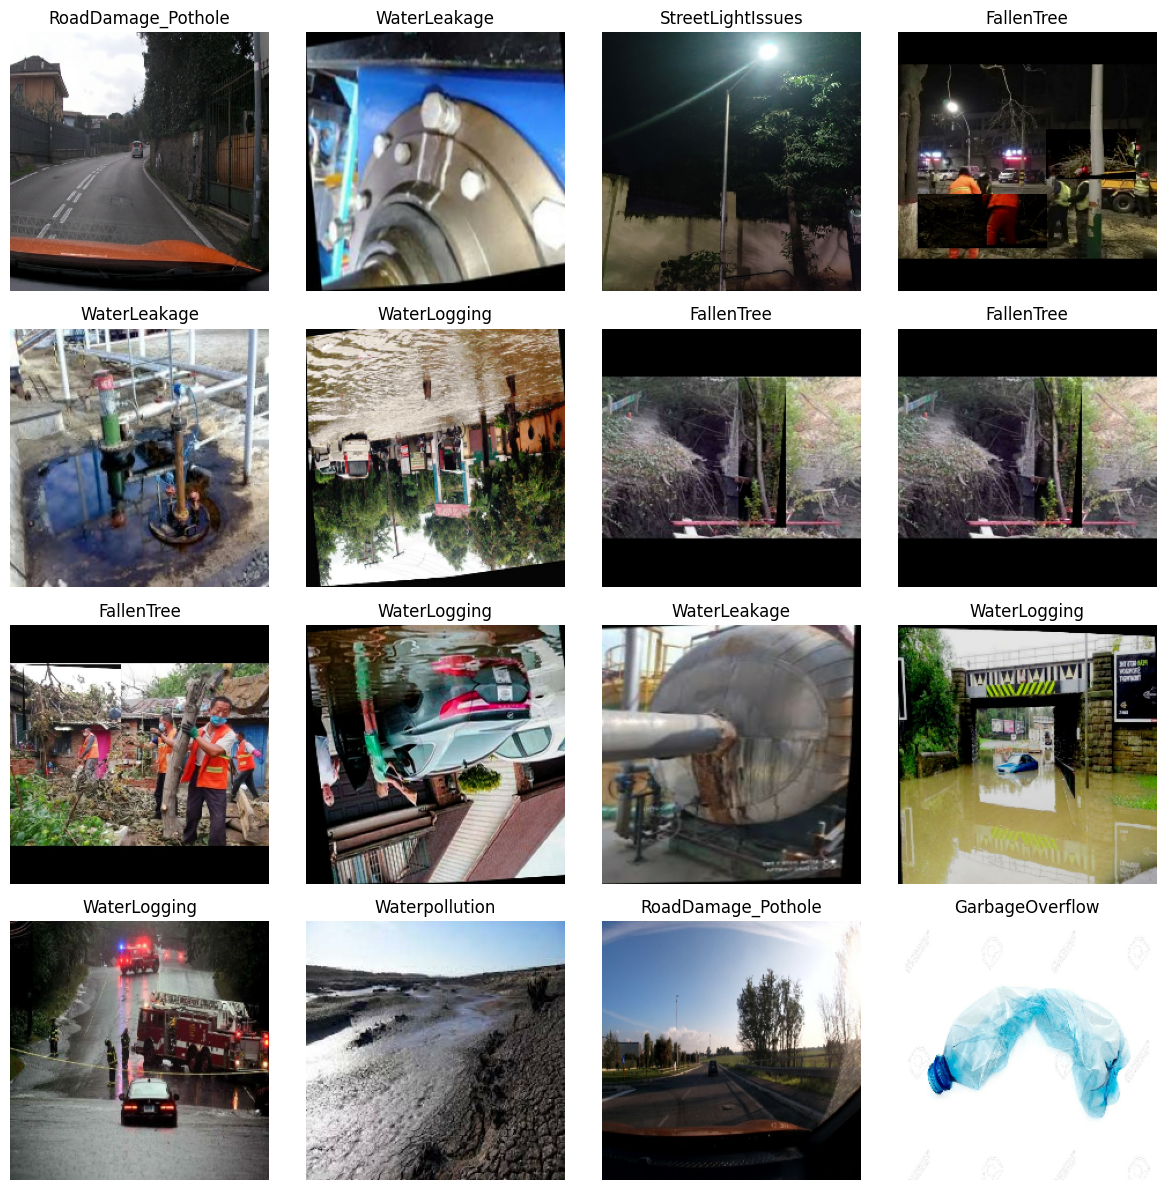

In [18]:
# ============================================================
# STEP 5.1 : Display Sample Images
# ============================================================

import matplotlib.pyplot as plt

# Get one batch from the training dataset
images, labels = next(iter(train_dataset))

plt.figure(figsize=(12, 12))

for i in range(16):
    plt.subplot(4, 4, i + 1)

    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

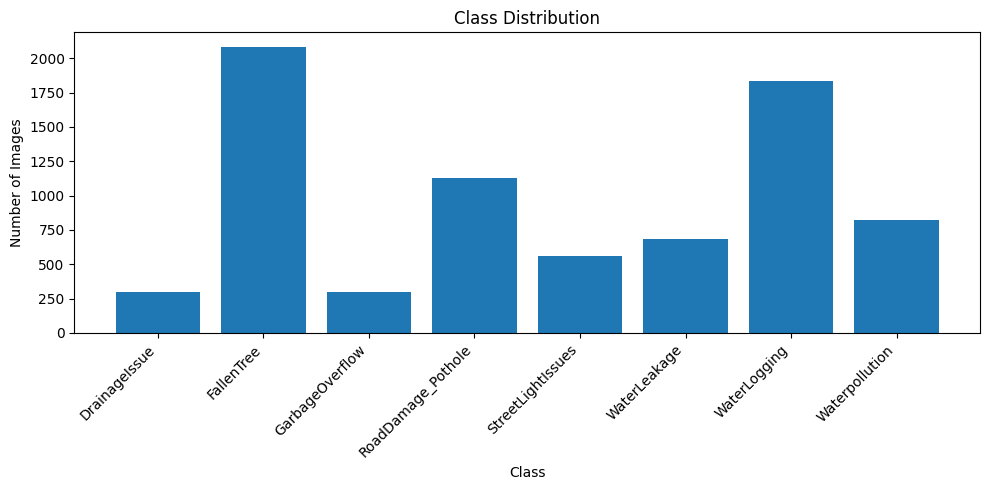

In [19]:
# ============================================================
# STEP 5.2 : Plot Class Distribution
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(summary_df["Class"], summary_df["Images"])

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# STEP 6 : Build EfficientNetV2B0 Model
# ============================================================

import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2B0

print("TensorFlow Version:", tf.__version__)
print("Keras Version:", tf.keras.__version__)

TensorFlow Version: 2.20.0
Keras Version: 3.13.2


In [21]:
# ============================================================
# Load EfficientNetV2B0 Backbone
# ============================================================

base_model = EfficientNetV2B0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained weights
base_model.trainable = False

print("✅ EfficientNetV2B0 loaded successfully.")

✅ EfficientNetV2B0 loaded successfully.


In [22]:
# ============================================================
# Build the Complete Model
# ============================================================

inputs = tf.keras.Input(shape=(224, 224, 3), name="input_image")

# Data augmentation
x = data_augmentation(inputs)

# Feature extraction
x = base_model(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)

x = layers.BatchNormalization(name="batch_norm")(x)

x = layers.Dense(
    256,
    activation="relu",
    name="dense_256"
)(x)

x = layers.Dropout(
    0.4,
    name="dropout"
)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax",
    name="classifier"
)(x)

model = Model(
    inputs,
    outputs,
    name="UrbanFix_EfficientNetV2B0"
)

print("✅ Model created successfully.")

✅ Model created successfully.


In [23]:
# ============================================================
# Model Summary
# ============================================================

model.summary(line_length=120)

Model: "UrbanFix_EfficientNetV2B0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                                        ┃ Output Shape                           ┃               Para
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━
│ input_image (InputLayer)                            │ (None, 224, 224, 3)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ data_augmentation (Sequential)                      │ (None, 224, 224, 3)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ efficientnetv2-b0 (Functional)                      │ (None, 7, 7, 1280)                     │             5,919,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ global_average_pooling (GlobalAveragePooling2D)     │ (None, 1280)                           │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ batch_norm (BatchNormalization)                     │ (None, 1280)                           │                 5,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ dense_256 (Dense)                                   │ (None, 256)                            │               327,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ dropout (Dropout)                                   │ (None, 256)                            │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ classifier (Dense)                                  │ (None, 8)                              │                 2,
└─────────────────────────────────────────────────────┴────────────────────────────────────────┴───────────────────

 Total params: 6,254,424 (23.86 MB)

 Trainable params: 332,552 (1.27 MB)

 Non-trainable params: 5,921,872 (22.59 MB)

In [24]:
# ============================================================
# STEP 7.1 : Compute Class Weights
# ============================================================

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Extract labels from training dataset
train_labels = np.concatenate(
    [labels.numpy() for _, labels in train_dataset],
    axis=0
)

# Compute balanced class weights
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = {
    i: float(weight)
    for i, weight in enumerate(weights)
}

print("=" * 50)
print("CLASS WEIGHTS")
print("=" * 50)

for idx, weight in class_weights.items():
    print(f"{class_names[idx]:<22}: {weight:.3f}")

CLASS WEIGHTS
DrainageIssue         : 3.068
FallenTree            : 0.456
GarbageOverflow       : 3.105
RoadDamage_Pothole    : 0.891
StreetLightIssues     : 1.692
WaterLeakage          : 1.413
WaterLogging          : 0.527
Waterpollution        : 1.186


In [25]:
# ============================================================
# STEP 7.2 : Compile the Model
# ============================================================

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model compiled successfully.")

✅ Model compiled successfully.


In [26]:
print("Optimizer :", model.optimizer)
print("Loss      :", model.loss)

Optimizer : <keras.src.optimizers.adam.Adam object at 0x7f96cc54f140>
Loss      : sparse_categorical_crossentropy


In [27]:
# ============================================================
# STEP 8.1 : Training Callbacks
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

checkpoint_path = MODEL_DIR / "UrbanFix_EfficientNetV2B0_Phase1.keras"

callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )

]

print("✅ Callbacks created successfully.")

✅ Callbacks created successfully.


In [28]:
# ============================================================
# STEP 8.2 : Phase 1 Training
# ============================================================

PHASE1_EPOCHS = 10

history_phase1 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=PHASE1_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.6111 - loss: 1.1849
Epoch 1: val_accuracy improved from None to 0.90513, saving model to /content/drive/MyDrive/UrbanFix/Models/UrbanFix_EfficientNetV2B0_Phase1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/UrbanFix/Models/UrbanFix_EfficientNetV2B0_Phase1.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 91s 365ms/step - accuracy: 0.7586 - loss: 0.7391 - val_accuracy: 0.9051 - val_loss: 0.3443 - learning_rate: 3.0000e-04
Epoch 2/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.8912 - loss: 0.3118
Epoch 2: val_accuracy improved from 0.90513 to 0.91423, saving model to /content/drive/MyDrive/UrbanFix/Models/UrbanFix_EfficientNetV2B0_Phase1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/UrbanFix/Models/UrbanFix_EfficientNetV2B0_Phase1.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 58s 300ms/step - accuracy: 0.8933 - loss: 0.3138 - val_accuracy: 0.9142 - val_loss: 0.2609 - learning_rate: 3.0000e-04
Epoch

In [29]:
# ============================================================
# STEP 9.1 : Fine-Tune EfficientNetV2B0
# ============================================================

# Unfreeze the backbone
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Trainable layers:")

trainable_count = 0

for layer in base_model.layers:
    if layer.trainable:
        trainable_count += 1

print(trainable_count)

Trainable layers:
30


In [30]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model recompiled for fine-tuning.")

✅ Model recompiled for fine-tuning.


In [31]:
FINE_TUNE_EPOCHS = 10

history_phase2 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9482 - loss: 0.1378
Epoch 1: val_accuracy did not improve from 0.95582
193/193 ━━━━━━━━━━━━━━━━━━━━ 76s 315ms/step - accuracy: 0.9472 - loss: 0.1394 - val_accuracy: 0.9324 - val_loss: 0.2039 - learning_rate: 1.0000e-05
Epoch 2/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9514 - loss: 0.1348
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.

Epoch 2: val_accuracy did not improve from 0.95582
193/193 ━━━━━━━━━━━━━━━━━━━━ 80s 305ms/step - accuracy: 0.9494 - loss: 0.1383 - val_accuracy: 0.9461 - val_loss: 0.1617 - learning_rate: 1.0000e-05
Epoch 3/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.9507 - loss: 0.1322
Epoch 3: val_accuracy did not improve from 0.95582
193/193 ━━━━━━━━━━━━━━━━━━━━ 82s 302ms/step - accuracy: 0.9526 - loss: 0.1256 - val_accuracy: 0.9506 - val_loss: 0.1461 - learning_rate: 2.0000e-06
Epoch 4/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accur

In [32]:
# ============================================================
# STEP 10.1 : Evaluate the Model
# ============================================================

test_loss, test_accuracy = model.evaluate(
    validation_dataset,
    verbose=1
)

print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)

print(f"Validation Loss     : {test_loss:.4f}")
print(f"Validation Accuracy : {test_accuracy:.4f}")

49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 231ms/step - accuracy: 0.9324 - loss: 0.2039
MODEL PERFORMANCE
Validation Loss     : 0.2039
Validation Accuracy : 0.9324


In [33]:
# ============================================================
# STEP 10.2 : Predict Validation Images
# ============================================================

import numpy as np

y_true = []
y_pred = []

for images, labels in validation_dataset:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("✅ Predictions generated.")

✅ Predictions generated.


In [34]:
# ============================================================
# STEP 10.3 : Classification Report
# ============================================================

from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

                    precision    recall  f1-score   support

     DrainageIssue     0.9231    0.9412    0.9320        51
        FallenTree     0.9973    0.9345    0.9649       397
   GarbageOverflow     0.7656    0.9608    0.8522        51
RoadDamage_Pothole     0.9922    0.9808    0.9865       261
 StreetLightIssues     0.9273    1.0000    0.9623       102
      WaterLeakage     0.8742    0.9635    0.9167       137
      WaterLogging     0.9494    0.8575    0.9011       372
    Waterpollution     0.8061    0.9405    0.8681       168

          accuracy                         0.9324      1539
         macro avg     0.9044    0.9474    0.9230      1539
      weighted avg     0.9383    0.9324    0.9333      1539



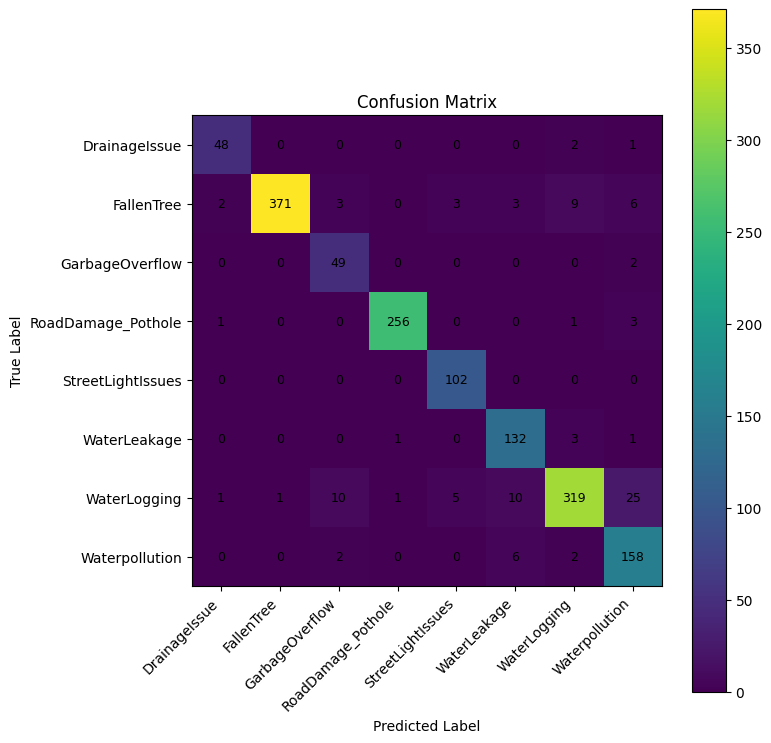

In [35]:
# ============================================================
# STEP 10.4 : Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))

plt.imshow(cm, interpolation="nearest")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# STEP 10.5 : Precision, Recall, F1 Score
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("=" * 50)
print("FINAL METRICS")
print("=" * 50)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

FINAL METRICS
Precision : 0.9383
Recall    : 0.9324
F1 Score  : 0.9333


In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
from pathlib import Path

print("Searching for saved Keras models...\n")

models = list(Path("/content/drive/MyDrive").rglob("*.keras"))

if models:
    for i, model_path in enumerate(models, 1):
        print(f"{i}. {model_path}")
else:
    print("No .keras models found.")

Searching for saved Keras models...

1. /content/drive/MyDrive/UrbanFix/Models/UrbanFix_EfficientNetV2B0.keras
2. /content/drive/MyDrive/UrbanFix/Models/UrbanFix_EfficientNetV2B0_Phase1.keras


In [39]:
import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/UrbanFix/Models/UrbanFix_EfficientNetV2B0_Phase1.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [40]:
model.summary()

Model: "UrbanFix_EfficientNetV2B0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,919,530 (26.40 MB)

 Trainable params: 332,552 (1.27 MB)

 Non-trainable params: 5,921,872 (22.59 MB)

 Optimizer params: 665,106 (2.54 MB)

In [ ]:
from google.colab import files

uploaded = files.upload()

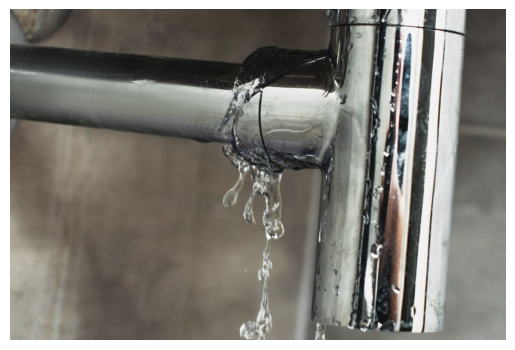

Prediction Result
Predicted Class : WaterLeakage
Confidence      : 100.00%


In [42]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Class names (same order as training)
class_names = [
    "DrainageIssue",
    "FallenTree",
    "GarbageOverflow",
    "RoadDamage_Pothole",
    "StreetLightIssues",
    "WaterLeakage",
    "WaterLogging",
    "Waterpollution"
]

# Get uploaded file
image_path = list(uploaded.keys())[0]

# Open image
image = Image.open(image_path).convert("RGB")

# Display image
plt.imshow(image)
plt.axis("off")
plt.show()

# Resize
image = image.resize((224, 224))

# Convert to numpy
image_array = np.array(image, dtype=np.float32)

# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)

# Predict
prediction = model.predict(image_array, verbose=0)

predicted_index = np.argmax(prediction)
confidence = prediction[0][predicted_index] * 100

print("=" * 50)
print("Prediction Result")
print("=" * 50)
print(f"Predicted Class : {class_names[predicted_index]}")
print(f"Confidence      : {confidence:.2f}%")